C:\Users\Admin\AppData\Local\Temp\ipykernel_2172\1164068521.py:4: DtypeWarning: Columns (1: name, 10: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Consumer_Reviews_of_Amazon_Products.csv")


Original: We like the Fire better than Roku. We also prefer the ease of use over the funtionality of our new Sony 4K TV.
Cleaned:  like better roku prefer ease use funtionality new sony k tv
(27700, 5000) (6926, 5000)
Baseline accuracy: 0.841
['Negative']
              precision    recall  f1-score   support

    Negative       0.25      0.54      0.34       162
     Neutral       0.15      0.42      0.22       300
    Positive       0.98      0.87      0.92      6464

    accuracy                           0.84      6926
   macro avg       0.46      0.61      0.49      6926
weighted avg       0.92      0.84      0.87      6926



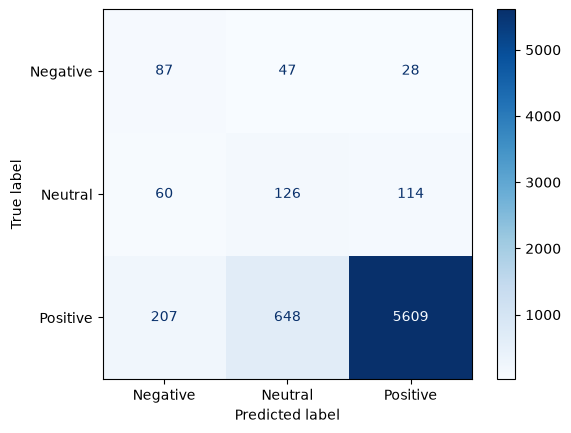

1104 / 6926 misclassified (15.9%)
              precision    recall  f1-score   support

    Negative       0.39      0.41      0.40       162
     Neutral       0.21      0.25      0.23       300
    Positive       0.96      0.95      0.96      6464

    accuracy                           0.91      6926
   macro avg       0.52      0.54      0.53      6926
weighted avg       0.91      0.91      0.91      6926

Logistic Regression macro-F1: 0.493
Linear SVM macro-F1:          0.529
Logistic Regression:
               precision    recall  f1-score   support

    Negative       0.25      0.54      0.34       162
     Neutral       0.15      0.42      0.22       300
    Positive       0.98      0.87      0.92      6464

    accuracy                           0.84      6926
   macro avg       0.46      0.61      0.49      6926
weighted avg       0.92      0.84      0.87      6926

Linear SVM:
               precision    recall  f1-score   support

    Negative       0.39      0.41      0.4

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/Consumer_Reviews_of_Amazon_Products.csv")
df = df.dropna(subset=['reviews.text', 'reviews.rating'])
df = df.drop_duplicates(subset=['reviews.text'])

def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)

X = df['reviews.text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Keep negations — removing them flips the meaning of a review
NEGATIONS = {"not", "no", "nor", "never", "n't", "none", "nothing"}
STOP_WORDS = ENGLISH_STOP_WORDS - NEGATIONS

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)       # remove punctuation/digits
    text = re.sub(r"\s+", " ", text).strip()     # collapse whitespace
    words = [w for w in text.split() if w not in STOP_WORDS]
    return " ".join(words)

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

# Sanity check — compare before/after on one example
print("Original:", X_train.iloc[0])
print("Cleaned: ", X_train_clean.iloc[0])


from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train_clean)
X_test_tfidf = vectorizer.transform(X_test_clean)

print(X_train_tfidf.shape, X_test_tfidf.shape)


from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf.fit(X_train_tfidf, y_train)


from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline accuracy: {baseline_accuracy:.3f}")


sample = ["This product broke after two days, terrible quality"]
sample_clean = [clean_text(s) for s in sample]
sample_tfidf = vectorizer.transform(sample_clean)
print(clf.predict(sample_tfidf))


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.show()


results_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred
})

misclassified = results_df[results_df['actual'] != results_df['predicted']]
print(f"{len(misclassified)} / {len(results_df)} misclassified ({len(misclassified)/len(results_df):.1%})")

misclassified.sample(10, random_state=42)



from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

svm_clf = LinearSVC(class_weight='balanced', random_state=42)
svm_clf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_clf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svm))

baseline_f1 = f1_score(y_test, y_pred, average='macro')
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
print(f"Logistic Regression macro-F1: {baseline_f1:.3f}")
print(f"Linear SVM macro-F1:          {svm_f1:.3f}")

print("Logistic Regression:\n", classification_report(y_test, y_pred))
print("Linear SVM:\n", classification_report(y_test, y_pred_svm))




## Model comparison and decision

Logistic Regression scored a macro-F1 of 0.49, and Linear SVM scored 0.53 — a 
4-point gap. The per-class breakdown explains why: with class_weight='balanced', 
Logistic Regression aggressively over-predicts the minority classes (Negative 
recall 0.54, Neutral recall 0.42), but at a steep precision cost — only 25% of 
its "Negative" predictions and 15% of its "Neutral" predictions are actually 
correct. 
Linear SVM trades some of that recall for much higher precision 
(0.39, 0.21) and a large gain on the dominant Positive class (F1 0.96 vs 0.92), 
driving its overall accuracy to 91% vs 84%.

I'm carrying forward **Linear SVM**. Its macro- and weighted-F1 are both 
meaningfully higher, and more importantly, Logistic Regression's low precision 
on Negative/Neutral (15–25%) means most of what it labels "Negative" or 
"Neutral" would be wrong if shown in the app. 
I'll lose SVM's built-in 
`predict_proba()` for the confidence display, so I'll wrap it in 
`CalibratedClassifierCV` in Week 4 to get calibrated probabilities without 
reverting to the weaker minority-class precision.